In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv")
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv")


In [8]:
austin_df.info()
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            15171 non-null  object 
 1   zipcode                         15171 non-null  int64  
 2   propertyTaxRate                 15171 non-null  float64
 3   garageSpaces                    15171 non-null  int64  
 4   hasAssociation                  15171 non-null  bool   
 5   hasCooling                      15171 non-null  bool   
 6   hasHeating                      15171 non-null  bool   
 7   hasSpa                          15171 non-null  bool   
 8   hasView                         15171 non-null  bool   
 9   parkingSpaces                   15171 non-null  int64  
 10  yearBuilt                       15171 non-null  int64  
 11  latestPrice                     15171 non-null  float64
 12  numPriceChanges                 

### Austin dataset regression

In [9]:

# Target variable
target_austin = 'latestPrice'

# Drop non-numeric columns
austin_features = austin_df.drop(columns=['city', 'latest_saledate', target_austin])

# Convert bools to integers (True/False → 1/0)
bool_cols = austin_features.select_dtypes(include='bool').columns
austin_features[bool_cols] = austin_features[bool_cols].astype(int)

# Define X and y
X_austin = austin_features
y_austin = austin_df[target_austin]

# Split data
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_austin, y_austin, test_size=0.2, random_state=42)

# Decision Tree Regressor
dt_austin = DecisionTreeRegressor(random_state=42)
dt_austin.fit(X_train_a, y_train_a)
y_pred_dt_austin = dt_austin.predict(X_test_a)

print("Austin Decision Tree R2:", r2_score(y_test_a, y_pred_dt_austin))
print("Austin Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test_a, y_pred_dt_austin)))

# Random Forest Regressor
rf_austin = RandomForestRegressor(n_estimators=100, random_state=42)
rf_austin.fit(X_train_a, y_train_a)
y_pred_rf_austin = rf_austin.predict(X_test_a)

print("Austin Random Forest R2:", r2_score(y_test_a, y_pred_rf_austin))
print("Austin Random Forest RMSE:", np.sqrt(mean_squared_error(y_test_a, y_pred_rf_austin)))

Austin Decision Tree R2: 0.3468518850252743
Austin Decision Tree RMSE: 393170.91827938106
Austin Random Forest R2: 0.5717228293718596
Austin Random Forest RMSE: 318374.30533985374


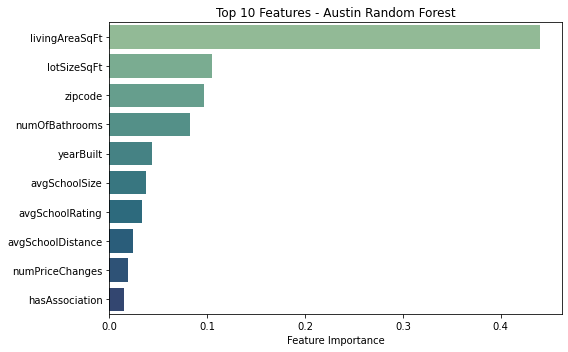

In [10]:
# ---------- Feature Importance: Austin ----------
importances_austin = pd.Series(rf_austin.feature_importances_, index=X_austin.columns)
top10_austin = importances_austin.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_austin.values, y=top10_austin.index, palette='crest')
plt.title("Top 10 Features - Austin Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


### Airbnb dataset regression


In [11]:

# Target variable
target_airbnb = 'price'

# Drop non-numeric and irrelevant columns
# Drop object columns (like 'name', 'host_name', 'last_scraped', etc.)
non_numeric_cols = airbnb_df.select_dtypes(include=['object']).columns.tolist()
# Also drop 'id' which is just an identifier
non_numeric_cols.append('id')

airbnb_features = airbnb_df.drop(columns=non_numeric_cols + [target_airbnb])

# Define X and y
X_airbnb = airbnb_features
y_airbnb = airbnb_df[target_airbnb]

# Split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_airbnb, y_airbnb, test_size=0.2, random_state=42)

# Decision Tree Regressor
dt_airbnb = DecisionTreeRegressor(random_state=42)
dt_airbnb.fit(X_train_b, y_train_b)
y_pred_dt_airbnb = dt_airbnb.predict(X_test_b)

print("Airbnb Decision Tree R2:", r2_score(y_test_b, y_pred_dt_airbnb))
print("Airbnb Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test_b, y_pred_dt_airbnb)))

# Random Forest Regressor
rf_airbnb = RandomForestRegressor(n_estimators=100, random_state=42)
rf_airbnb.fit(X_train_b, y_train_b)
y_pred_rf_airbnb = rf_airbnb.predict(X_test_b)

print("Airbnb Random Forest R2:", r2_score(y_test_b, y_pred_rf_airbnb))
print("Airbnb Random Forest RMSE:", np.sqrt(mean_squared_error(y_test_b, y_pred_rf_airbnb)))

Airbnb Decision Tree R2: -0.23456973153825333
Airbnb Decision Tree RMSE: 550.4204690811426
Airbnb Random Forest R2: 0.6852643761133341
Airbnb Random Forest RMSE: 277.9135454013096


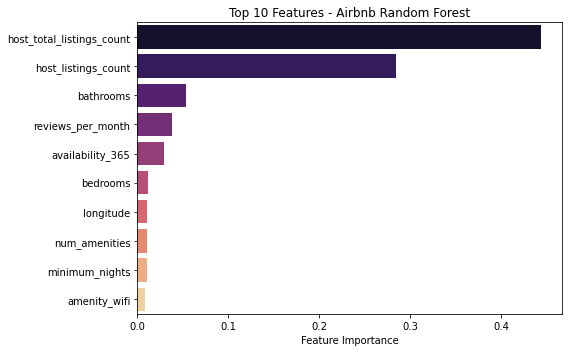

In [12]:
# ---------- Feature Importance: Airbnb ----------
importances_airbnb = pd.Series(rf_airbnb.feature_importances_, index=X_airbnb.columns)
top10_airbnb = importances_airbnb.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10_airbnb.values, y=top10_airbnb.index, palette='magma')
plt.title("Top 10 Features - Airbnb Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

### Cross-Validation + Hyperparameter Tuning 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [28]:
# ---------------------------
# Preprocessing Function
# ---------------------------
def prepare_data(df, target, drop_cols=[]):
    df = df.drop(columns=drop_cols, errors='ignore')
    df = df.dropna()
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# Model Evaluation Function
# ---------------------------
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} - R2: {r2:.4f}, RMSE: {rmse:.2f}")

# ---------------------------
# GridSearch Wrapper
# ---------------------------
def run_gridsearch(model, param_grid, X_train, y_train):
    grid = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

# ---------------------------
# Function to plot RMSE vs max_depth for Decision Tree
# ---------------------------
def plot_rmse_vs_max_depth(X_train, X_test, y_train, y_test, depths, dataset_name):
    rmse_list = []
    for depth in depths:
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmse_list.append(rmse)
        print(f"{dataset_name} Decision Tree - max_depth={depth}, RMSE={rmse:.2f}")
    plt.figure(figsize=(8,5))
    plt.plot(depths, rmse_list, marker='o')
    plt.xlabel('max_depth')
    plt.ylabel('RMSE')
    plt.title(f'Decision Tree max_depth vs RMSE ({dataset_name} Dataset)')
    plt.grid(True)
    plt.show()

# ---------------------------
# Load datasets
# ---------------------------
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv")
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/listings_cleaned.csv")


=== Austin Dataset ===
Austin Decision Tree - max_depth=3, RMSE=380029.86
Austin Decision Tree - max_depth=5, RMSE=363513.69
Austin Decision Tree - max_depth=7, RMSE=368892.17
Austin Decision Tree - max_depth=10, RMSE=396814.66
Austin Decision Tree - max_depth=15, RMSE=397886.68


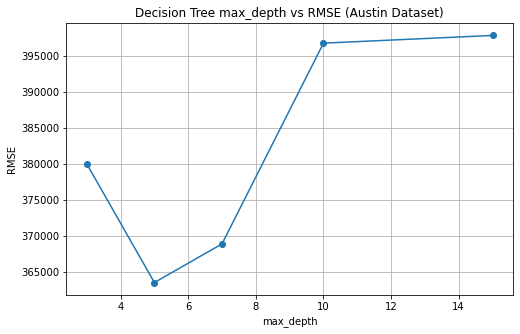

Austin Decision Tree - R2: 0.3898, RMSE: 380029.86
Best DT params: {'max_depth': 3}
Austin Random Forest - R2: 0.5719, RMSE: 318292.08
Best RF params: {'max_depth': 15, 'n_estimators': 50}


In [29]:
# ---------------------------
# Austin Dataset Model Tuning
# ---------------------------
print("=== Austin Dataset ===")
X_train_a, X_test_a, y_train_a, y_test_a = prepare_data(
    austin_df,
    target='latestPrice',
    drop_cols=['city', 'latest_saledate']
)

# Plot RMSE vs max_depth for Austin Decision Tree
depths_to_test = [3, 5, 7, 10, 15]
plot_rmse_vs_max_depth(X_train_a, X_test_a, y_train_a, y_test_a, depths_to_test, "Austin")

# Decision Tree GridSearch
dt_model_austin, dt_params_austin = run_gridsearch(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': depths_to_test},
    X_train_a,
    y_train_a
)
evaluate_model("Austin Decision Tree", dt_model_austin, X_test_a, y_test_a)
print("Best DT params:", dt_params_austin)

# Random Forest GridSearch
rf_model_austin, rf_params_austin = run_gridsearch(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50], 'max_depth': [5, 10, 15]},
    X_train_a,
    y_train_a
)
evaluate_model("Austin Random Forest", rf_model_austin, X_test_a, y_test_a)
print("Best RF params:", rf_params_austin)


=== Airbnb Dataset ===
Airbnb Decision Tree - max_depth=3, RMSE=267.84
Airbnb Decision Tree - max_depth=5, RMSE=275.68
Airbnb Decision Tree - max_depth=7, RMSE=439.38
Airbnb Decision Tree - max_depth=10, RMSE=521.68
Airbnb Decision Tree - max_depth=15, RMSE=551.68


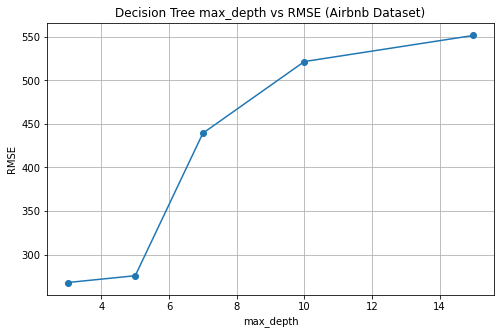

Airbnb Decision Tree - R2: 0.6903, RMSE: 275.68
Best DT params: {'max_depth': 5}
Airbnb Random Forest - R2: 0.6426, RMSE: 296.17
Best RF params: {'max_depth': 15, 'n_estimators': 50}


In [30]:
# ---------------------------
# Airbnb Dataset Model Tuning
# ---------------------------
print("\n=== Airbnb Dataset ===")
drop_cols_airbnb = airbnb_df.select_dtypes(include=['object']).columns.tolist() + ['id']
X_train_b, X_test_b, y_train_b, y_test_b = prepare_data(
    airbnb_df,
    target='price',
    drop_cols=drop_cols_airbnb
)

# Plot RMSE vs max_depth for Airbnb Decision Tree
plot_rmse_vs_max_depth(X_train_b, X_test_b, y_train_b, y_test_b, depths_to_test, "Airbnb")

# Decision Tree GridSearch
dt_model_airbnb, dt_params_airbnb = run_gridsearch(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': depths_to_test},
    X_train_b,
    y_train_b
)
evaluate_model("Airbnb Decision Tree", dt_model_airbnb, X_test_b, y_test_b)
print("Best DT params:", dt_params_airbnb)

# Random Forest GridSearch
rf_model_airbnb, rf_params_airbnb = run_gridsearch(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50], 'max_depth': [5, 10, 15]},
    X_train_b,
    y_train_b
)
evaluate_model("Airbnb Random Forest", rf_model_airbnb, X_test_b, y_test_b)
print("Best RF params:", rf_params_airbnb)